E[Li] = P(Claim_i = 1) * E[Severity_i | Claim_i = 1]

Frequency Model: Use frequency data to train a classifier to predict the probability of filing claim
Severity Model: Use severity data to train a regression model to predict severity of claim for those who have already had an accident.
Multiply the predicted probability by the predicted severity to get the Expected Cost

Import packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
import statsmodels.api as sm

Load the datasets

In [3]:
df_freq=pd.read_csv('consulting/frequency.csv')
df_sev=pd.read_csv('consulting/severity.csv')
print(df_freq.shape,df_sev.shape)

(24774, 11) (12256, 11)


In [4]:
df_freq.head(5)

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimNumbMD
0,2009,Male,C,Large,Employed,25,3,15080,0,72.012883,1
1,2009,Male,E,Large,Employed,20,2,22370,1,39.550411,1
2,2009,Female,E,Large,Unemployed,42,0,39650,0,169.529148,1
3,2009,Female,C,Medium,Housewife,21,0,12600,1,58.894688,1
4,2009,Female,D,Large,Employed,33,10,9065,0,109.631885,1


In [5]:
df_sev.head(5)

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimSizeMD
0,2009,Female,A,Medium,Housewife,41,0,24940,1,273,740
1,2009,Male,B,Small,Unemployed,25,12,48945,0,190,207
2,2009,Female,E,Small,Employed,29,7,1525,0,225,803
3,2009,Male,A,Small,Self-employed,47,12,18480,1,129,868
4,2009,Female,C,Large,Employed,47,7,8690,0,290,1746


Basic EDA

   Freq_Mean_Age  Sev_Mean_Age  Freq_Mean_CarVal  Sev_Mean_CarVal
0      38.554937     34.986945      16772.358521     17114.161635


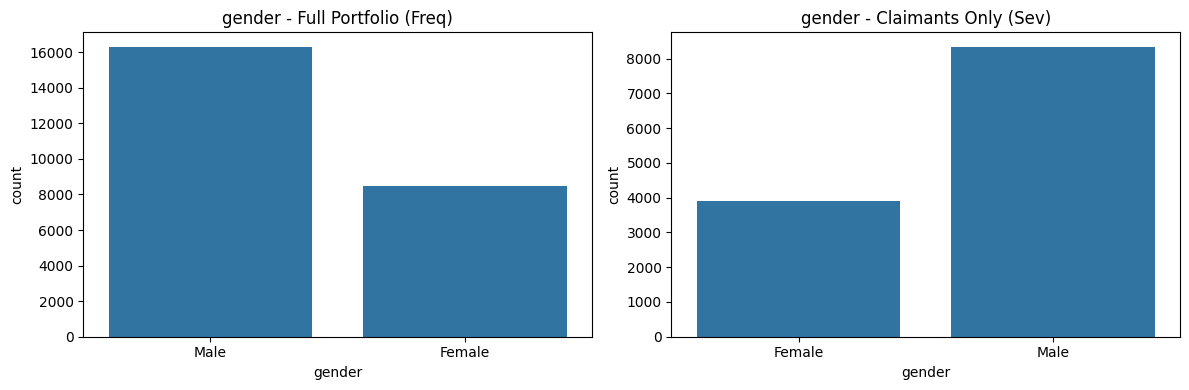

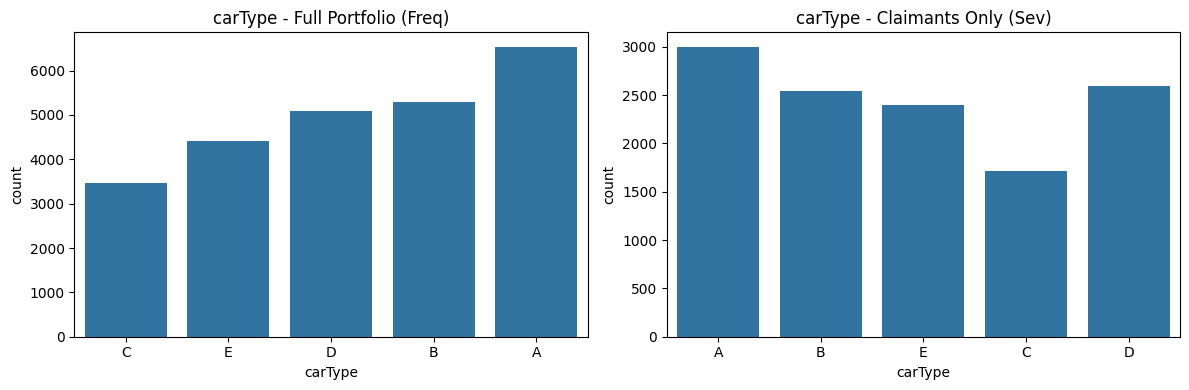

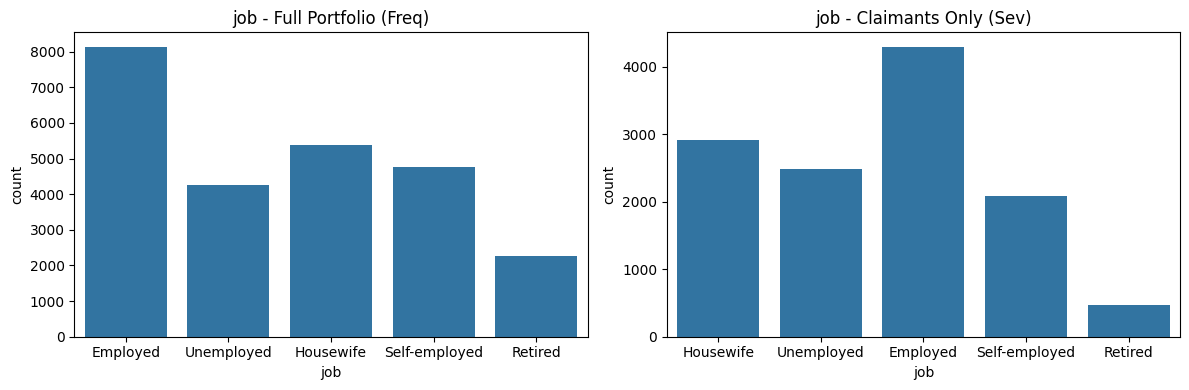

In [11]:
comparison = pd.DataFrame({
    'Freq_Mean_Age': [df_freq['age'].mean()],
    'Sev_Mean_Age': [df_sev['age'].mean()],
    'Freq_Mean_CarVal': [df_freq['carVal'].mean()],
    'Sev_Mean_CarVal': [df_sev['carVal'].mean()]
})
print(comparison)

def plot_categorical_dist(col):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.countplot(data=df_freq, x=col, ax=ax[0])
    ax[0].set_title(f'{col} - Full Portfolio (Freq)')
    
    sns.countplot(data=df_sev, x=col, ax=ax[1])
    ax[1].set_title(f'{col} - Claimants Only (Sev)')
    
    plt.tight_layout()
    plt.show()

for col in ['gender', 'carType', 'job']:
    plot_categorical_dist(col)

Claimants are younger than the general portfolio meaning younger drivers may be higher risk -- find literature on this?
Car Values are very close so might not have as strong an effect maybe for claim filing

Portfolio and claimants are heavily Male but there is a bias in the portfolio itself
Retirees are a decent chunk of the portfolio but a tiny sliver of claimants -- maybe they drive less or more safer (same age factor at play here)

carType A is the most common in both


Overall Portfolio Claim Rate: 49.56%


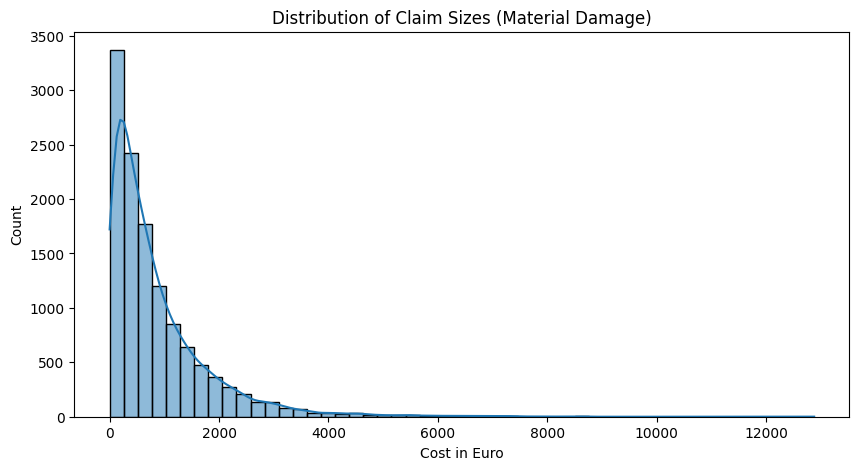

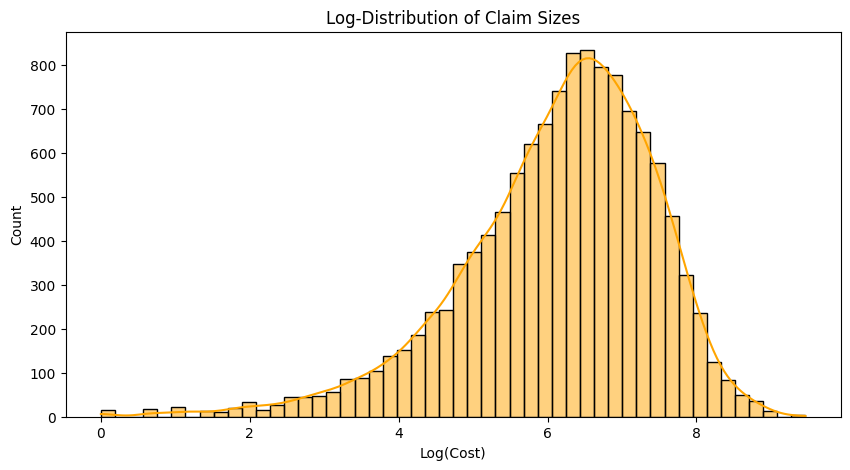

In [12]:
claim_rate = df_freq['claimNumbMD'].mean()
print(f"\nOverall Portfolio Claim Rate: {claim_rate:.2%}")

plt.figure(figsize=(10, 5))
sns.histplot(df_sev['claimSizeMD'], bins=50, kde=True)
plt.title("Distribution of Claim Sizes (Material Damage)")
plt.xlabel("Cost in Euro")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(np.log(df_sev['claimSizeMD']), bins=50, kde=True, color='orange')
plt.title("Log-Distribution of Claim Sizes")
plt.xlabel("Log(Cost)")
plt.show()

heavy Right Skew meaning most claims are small but with a long tail of expensive claims
Log-Distribution is nearly a Bell Curve - Gamma GLM with a Log-link or a Log-Normal model?

Data Cleaning

Missing Values in Frequency Data:
uwYear         0
gender         0
carType        0
carCat         0
job            0
age            0
nYears         0
carVal         0
cover          0
density        0
claimNumbMD    0
dtype: int64

Missing Values in Severity Data:
uwYear         0
gender         0
carType        0
carCat         0
job            0
age            0
nYears         0
carVal         0
cover          0
density        0
claimSizeMD    0
dtype: int64

Health Check Summary:
{'Min Age': 18, 'Max Age': 75, 'Zero/Negative Claims': 4, 'Max Claim': 12878, 'Freq_Number of Years Min': 0, 'Freq_Number of Years Max': 15, 'Sev_Number of Years Min': 0, 'Sev_Number of Years Max': 15, 'Freq_Density Min': 14.37714238, 'Freq_Density Max': 297.3851697, 'Sev_Density Min': 14, 'Sev_Density Max': 297}


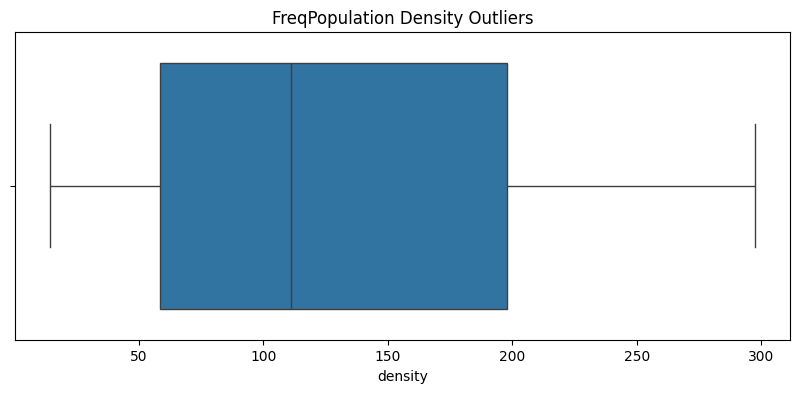

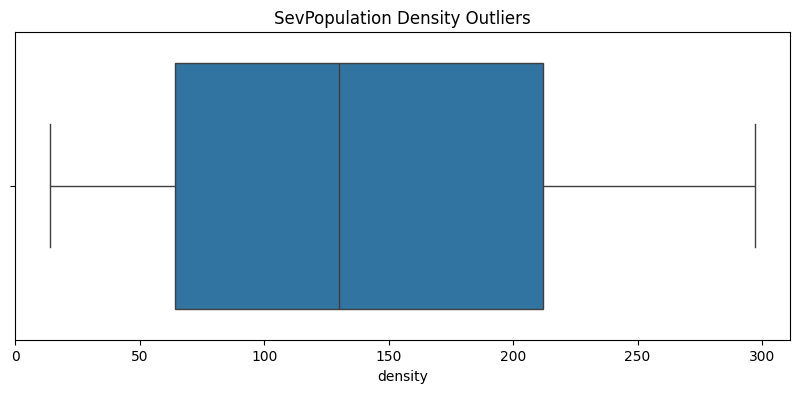

In [15]:
print("Missing Values in Frequency Data:")
print(df_freq.isnull().sum())

print("\nMissing Values in Severity Data:")
print(df_sev.isnull().sum())

health_check = {
    "Min Age": df_freq['age'].min(),
    "Max Age": df_freq['age'].max(),
    "Zero/Negative Claims": (df_sev['claimSizeMD'] <= 0).sum(),
    "Max Claim": df_sev['claimSizeMD'].max(),
    "Freq_Number of Years Min" : df_freq['nYears'].min(),
    "Freq_Number of Years Max" : df_freq['nYears'].max(),
    "Sev_Number of Years Min" : df_sev['nYears'].min(),
    "Sev_Number of Years Max" : df_sev['nYears'].max(),
    "Freq_Density Min" : df_freq['density'].min(),
    "Freq_Density Max" : df_freq['density'].max(),
    "Sev_Density Min" : df_sev['density'].min(),
    "Sev_Density Max" : df_sev['density'].max(),
}
print("\nHealth Check Summary:")
print(health_check)

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_freq['density'])
plt.title("FreqPopulation Density Outliers")

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_sev['density'])
plt.title("SevPopulation Density Outliers")
plt.show()

No Missing Values for both datasets.
4 records where claimSizeMD is 0 out of 12,256 claimants and must be handled since Gamma  and Log-links cannot process 0
Age range is sensible (18 to 75) 
nYears - mix of new and loyal customers (0 to 15)

Density - no extreme outliers
Claim Max: 12,878 Euro is a significant but not impossible car repair bill

Feature Engineering

In [6]:
df_sev = df_sev[df_sev['claimSizeMD'] > 0].copy()

def engineer_features(df):
    df['is_young'] = (df['age'] < 25).astype(int)
    df['driving_years'] = df['age'] - 18
    df['loyalty_index'] = df['nYears'] / (df['age'] - 17) 
    
    df['log_carVal'] = np.log1p(df['carVal'])
    df['log_density'] = np.log1p(df['density'])
    avg_val_cat = df.groupby('carCat')['carVal'].transform('mean')
    df['relative_car_val'] = df['carVal'] / avg_val_cat
    
    df['val_density_interaction'] = df['log_carVal'] * df['log_density']
    df['is_new_policy'] = (df['nYears'] == 0).astype(int)

    cat_cols = ['gender', 'carType', 'carCat', 'job', 'cover']
    for col in cat_cols:
        df[col] = df[col].astype(str)

    df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

    return df


freq_eng = engineer_features(df_freq)
sev_eng = engineer_features(df_sev)


In [7]:
freq_eng.head(5)

,uwYear,age,nYears,carVal,density,claimNumbMD,is_young,driving_years,loyalty_index,log_carVal,...,carType_C,carType_D,carType_E,carCat_Medium,carCat_Small,job_Housewife,job_Retired,job_Self-employed,job_Unemployed,cover_1
0,2009,25,3,15080,72.012883,1,0,7,0.375000,9.621191,...,1,0,0,0,0,0,0,0,0,0
1,2009,20,2,22370,39.550411,1,1,2,0.666667,10.015521,...,0,0,1,0,0,0,0,0,0,1
2,2009,42,0,39650,169.529148,1,0,24,0.000000,10.587871,...,0,0,1,0,0,0,0,0,1,0
3,2009,21,0,12600,58.894688,1,1,3,0.000000,9.441531,...,1,0,0,1,0,1,0,0,0,1
4,2009,33,10,9065,109.631885,1,0,15,0.625000,9.112286,...,0,1,0,0,0,0,0,0,0,0


In [8]:
sev_eng.head(5)

,uwYear,age,nYears,carVal,density,claimSizeMD,is_young,driving_years,loyalty_index,log_carVal,...,carType_C,carType_D,carType_E,carCat_Medium,carCat_Small,job_Housewife,job_Retired,job_Self-employed,job_Unemployed,cover_1
0,2009,41,0,24940,273,740,0,23,0.000000,10.124268,...,0,0,0,1,0,1,0,0,0,1
1,2009,25,12,48945,190,207,0,7,1.500000,10.798473,...,0,0,0,0,1,0,0,0,1,0
2,2009,29,7,1525,225,803,0,11,0.583333,7.330405,...,0,0,1,0,1,0,0,0,0,0
3,2009,47,12,18480,129,868,0,29,0.400000,9.824498,...,0,0,0,0,1,0,0,1,0,1
4,2009,47,7,8690,290,1746,0,29,0.233333,9.070043,...,1,0,0,0,0,0,0,0,0,0


Demographic 
is_young (Age < 25) - binary flag for drivers under 25 since historically, younger drivers exhibit higher Claim Frequency due to lack of experience
driving_years - estimation of total years of driving experience by assuming they learn at 18
loyalty_index (nYears / (Age - 17)) - measures the proportion of life they have spent with the insurer -> proxy for customer stability/retention

Exposure/Economic 
log_carVal & log_density - natural log transformation to car value and population density to fix right-skew
relative_car_val (carVal / Group Mean) - compares a car's value to the average value within its specific category - cheap in a luxury cat might carry different risks (older car but still higher maintenance) than expensive in a budget category
val_density_interaction (log_carVal * log_density) -  attempt at capturing compound risk

Operational 
is_new_policy (nYears == 0) - policies in their first year. -> new customers 
One-Hot Encoding of gender, carType into binary columns

Filter (df_sev['claimSizeMD'] > 0) - train on actual losses Including zeros

In [12]:
analysis = freq_eng.groupby('is_new_policy')['claimNumbMD'].mean()
print("Claim Rate - New vs Existing Policies:")
print(analysis)

Claim Rate - New vs Existing Policies:
is_new_policy
0    0.484375
1    0.558903
Name: claimNumbMD, dtype: float64


Existing Policies (0): Have a claim rate of approximately 48.4%.  
New Policies (1): Have a claim rate of approximately 55.9%.  
New policies show a 7.5% point increase in claim frequency compared to existing ones

the insurer has less historical data to accurately price these individuals compared to existing clients and new applicants might be seeking insurance specifically because their risk profile has changed
lower rate for existing policies validates using loyalty_index

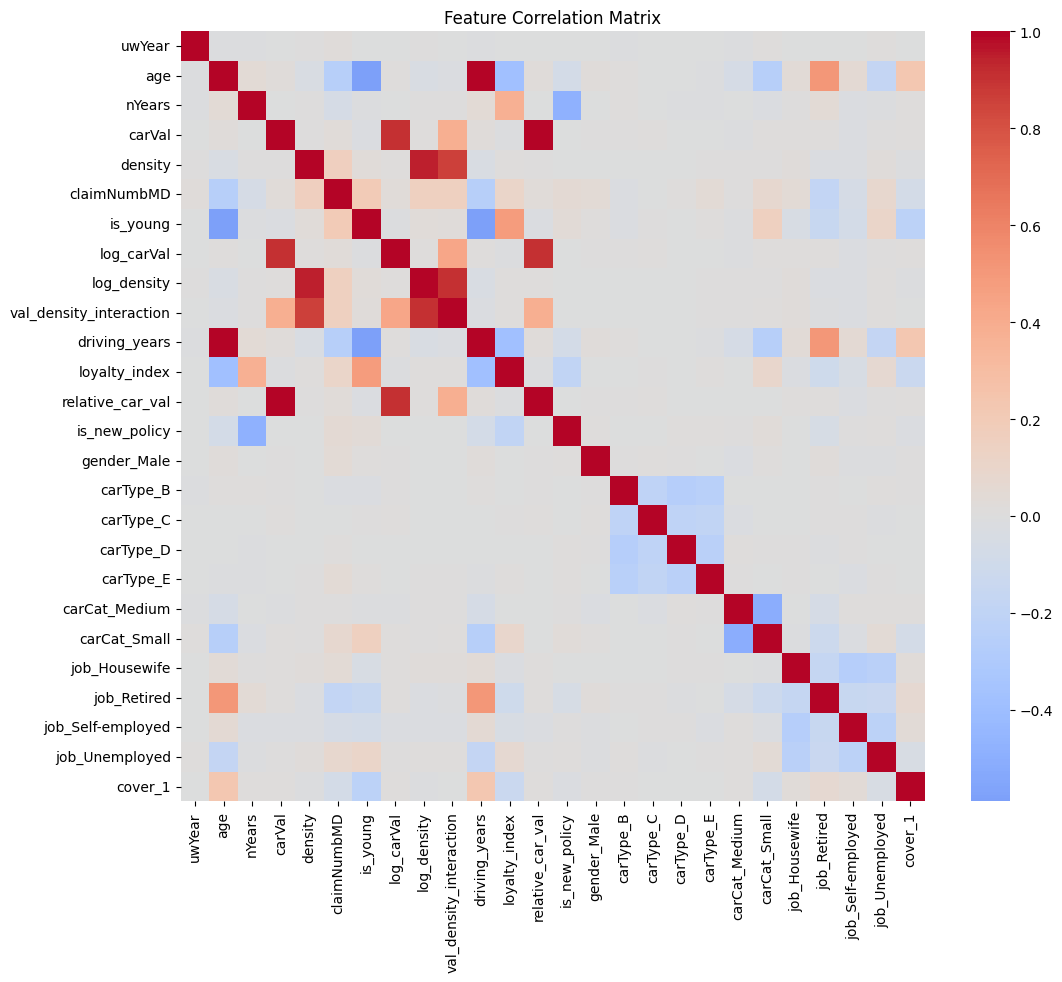

age               driving_years       1.000000
cover_1           cover_1             1.000000
relative_car_val  carVal              0.999957
carVal            relative_car_val    0.999957
log_density       density             0.950344
density           log_density         0.950344
log_carVal        carVal              0.908933
carVal            log_carVal          0.908933
log_carVal        relative_car_val    0.908904
relative_car_val  log_carVal          0.908904
dtype: float64


In [27]:
corr = freq_eng.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

high_corr = corr.abs().unstack().sort_values(ascending=False)
print(high_corr[len(freq_eng.columns) : len(freq_eng.columns) + 10])

Multicollinearity between age and driving_years which is obvious since driving_years = age - 18
for GLM, including both could lead to unstable coefficients but for a tree-based model like XGBoost, this is less problematic
Density Cluster - strong positive correlation between density, log_density, and val_density_interaction
Car Value Cluster - carVal, log_carVal, and relative_car_val show strong alignment
Negative Correlation between age and is_young - perfect inverse relationship

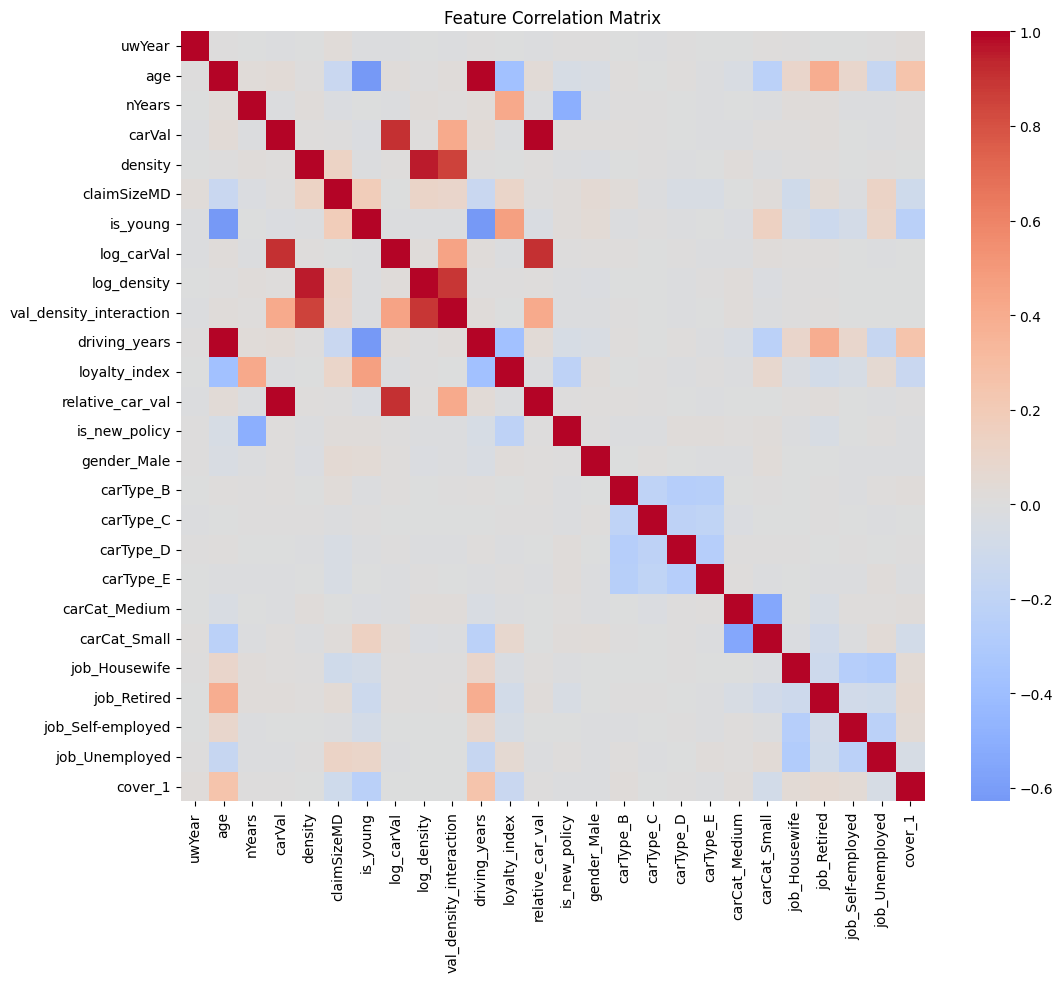

age               driving_years       1.000000
cover_1           cover_1             1.000000
carVal            relative_car_val    0.999914
relative_car_val  carVal              0.999914
log_density       density             0.951383
density           log_density         0.951383
carVal            log_carVal          0.909896
log_carVal        carVal              0.909896
relative_car_val  log_carVal          0.909792
log_carVal        relative_car_val    0.909792
dtype: float64


In [33]:
corr = sev_eng.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

high_corr = corr.abs().unstack().sort_values(ascending=False)
print(high_corr[len(sev_eng.columns) : len(sev_eng.columns) + 10])

claimSizeMD has relatively low linear correlation with most individual features compared to the frequency clusters which apparently is common in insurance wherein frequency is driven by behavior whereas severity is often driven by random physics and high-value assets 
Positive Correlation with Car Value (carVal, log_carVal) -> more expensive vehicles lead to higher repair costs 
positive correlation with density and log_density -> accidents in high-density areas involves more complex multi-car collisions or higher labor costs negative Correlation with experience (nYears, age) -> older, more experienced drivers might be involved in less severe accidents

possibly using a Gamma distribution with a log link, to handle the positive-only, right-skewed nature of these varied costs may work

C:\Users\athul\AppData\Local\Temp\ipykernel_28916\3541255084.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_profile = freq_eng.groupby('age_bin')['claimNumbMD'].mean()
C:\Users\athul\AppData\Local\Temp\ipykernel_28916\3541255084.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_profile_sev = sev_eng.groupby('age_bin')['claimSizeMD'].mean()


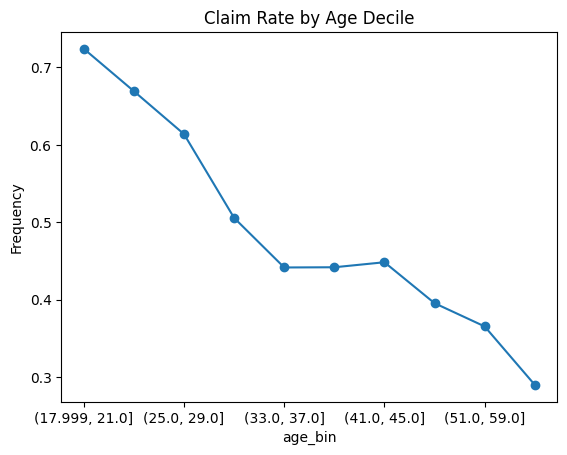

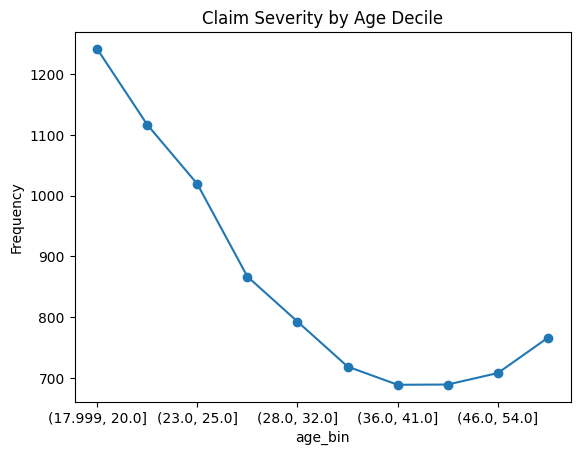

In [13]:
# Binning Age to check for the 'U-Shape'
freq_eng['age_bin'] = pd.qcut(freq_eng['age'], q=10)
age_profile = freq_eng.groupby('age_bin')['claimNumbMD'].mean()
sev_eng['age_bin'] = pd.qcut(sev_eng['age'], q=10)
age_profile_sev = sev_eng.groupby('age_bin')['claimSizeMD'].mean()

age_profile.plot(kind='line', marker='o')
plt.title("Claim Rate by Age Decile")
plt.ylabel("Frequency")
plt.show()

age_profile_sev.plot(kind='line', marker='o')
plt.title("Claim Severity by Age Decile")
plt.ylabel("Frequency")
plt.show()

a nearly continuous decline in claim probability from the youngest decile (~18–21) to the oldest deciles (~59+)
youngest drivers have the highest claim rate, exceeding 70% in the first decile and decline plateaus slightly between ages 33 and 45 before dropping further in the senior years
Unlike frequency, severity is not linear -> starts very high for young drivers reaches a trough around ages 36–45 and then rises again for older drivers
After age 45, the average cost per claim starts an upward trend, even though these drivers are having accidents less often 

Young drivers often have high-severity claims due to high-speed impacts or lack of hazard perception
Middle-aged drivers are typically at the sweet spot of experience and caution
Older drivers may experience rising severity due to slower reaction times or potentially more fragile health, leading to higher medical or vehicle damage costs per incident

In [14]:
def calculate_woe_iv(df, feature, target):
    if df[feature].nunique() > 10:
        df['temp_bin'] = pd.qcut(df[feature], q=10, duplicates='drop')
    else:
        df['temp_bin'] = df[feature]
        
    stats = df.groupby('temp_bin')[target].agg(['count', 'sum'])
    stats.columns = ['Total', 'Claims']
    stats['Non-Claims'] = stats['Total'] - stats['Claims']
    
    perc_claims = stats['Claims'] / stats['Claims'].sum()
    perc_non_claims = stats['Non-Claims'] / stats['Non-Claims'].sum()
    
    stats['WoE'] = np.log((perc_claims + 0.0001) / (perc_non_claims + 0.0001))
    stats['IV'] = (perc_claims - perc_non_claims) * stats['WoE']
    
    total_iv = stats['IV'].sum()
    return total_iv, stats[['WoE', 'IV']]

for col in ['age', 'log_density', 'carVal', 'nYears']:
    iv, table = calculate_woe_iv(freq_eng, col, 'claimNumbMD')
    print(f"Information Value for {col}: {iv:.4f}")


Information Value for age: 0.2984
Information Value for log_density: 0.1067
Information Value for carVal: 0.0051
Information Value for nYears: 0.0143


C:\Users\athul\AppData\Local\Temp\ipykernel_28916\2793805741.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby('temp_bin')[target].agg(['count', 'sum'])
C:\Users\athul\AppData\Local\Temp\ipykernel_28916\2793805741.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby('temp_bin')[target].agg(['count', 'sum'])
C:\Users\athul\AppData\Local\Temp\ipykernel_28916\2793805741.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future

Weight of Evidence - Measures the strength of a specific bin in predicting a claim versus a non-claim
positive WoE indicates a higher concentration of claims in that group
Information Value (IV) - single numeric value that summarizes the overall predictive power of a feature which helps in feature selection

Age - strongest predictor
log_density - medium predictor (geographic location and population density have a meaningful impact)
nYears - weak predictor
carVal - value of a car does not significantly change the probability of a crash, even though we know it changes the cost (severity)

Since calculate_woe_iv bins the data, it captures non-linear relationships 

In [15]:
# keep log_density and age 
# drop carVal because its IV (0.0051) is basically zero 
cols_to_drop_freq = ['log_carVal', 'density','relative_car_val','temp_bin']

df_freq_fin = freq_eng.drop(columns=cols_to_drop_freq)

# drop density and log_density 
cols_to_drop_sev = ['density', 'relative_car_val','log_carVal'] 

df_sev_fin = sev_eng.drop(columns=cols_to_drop_sev)

print(f"Frequency features remaining: {len(df_freq_fin.columns)}")
print(f"Severity features remaining: {len(df_sev_fin.columns)}")

Frequency features remaining: 24
Severity features remaining: 24


Frequency Model Adjustment -> retaining age and log_density & removing carVal and its derivatives 
Severity Model Adjustment -> removing density and its log-transformed version

dropping variables with near-zero IV, to reduce noise 
dropping density and log_carVal while keeping their more predictive counterparts prevents double counting

C:\Users\athul\AppData\Local\Temp\ipykernel_28916\2793805741.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby('temp_bin')[target].agg(['count', 'sum'])


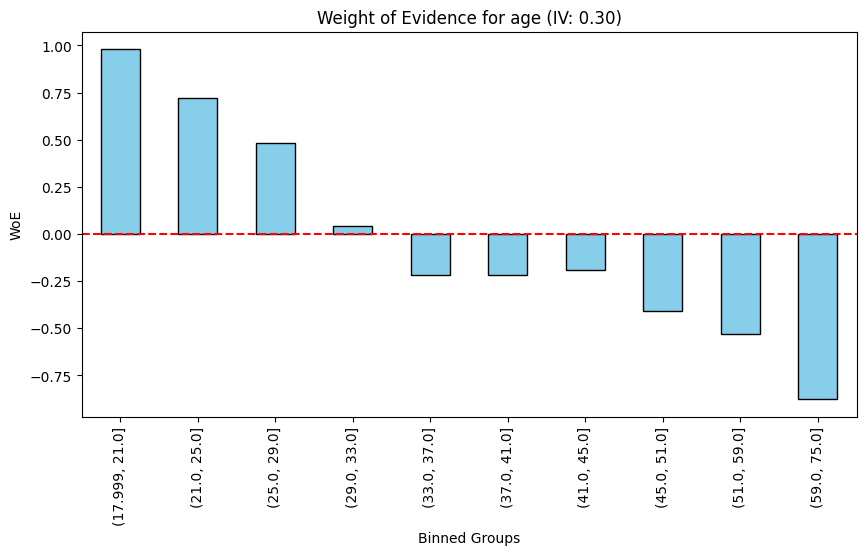

In [16]:
def plot_woe(df, feature, target):
    iv, stats = calculate_woe_iv(df, feature, target)
    
    plt.figure(figsize=(10, 5))
    stats['WoE'].plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f"Weight of Evidence for {feature} (IV: {iv:.2f})")
    plt.axhline(y=0, color='r', linestyle='--')
    plt.ylabel("WoE")
    plt.xlabel("Binned Groups")
    plt.show()

plot_woe(df_freq_fin, 'age', 'claimNumbMD')

red dashed line represents the average risk of the entire portfolio
positive WoE  - group has a higher-than-average proportion of claims whereas negative WoE - group has a lower-than-average proportion of claims 
monotonic decreasing trend -> as age increases, the risk of a claim consistently decreases
age group (17.99, 21.0] has the highest WoE (nearly 1.0) and risk remains above average until age 33
drivers aged 33 to 75 are statistically safe compared to the portfolio average
oldest group (59.0, 75.0] has the lowest WoE - lowest frequency risk

While age itself might have a non-linear relationship with claims, the WoE-transformed age is linear relative to the log-odds of a claim

In [17]:
print("Final Frequency Columns:", df_freq_fin.columns.tolist())
print("\nFinal Severity Columns:", df_sev_fin.columns.tolist())

Final Frequency Columns: ['uwYear', 'age', 'nYears', 'carVal', 'claimNumbMD', 'is_young', 'driving_years', 'loyalty_index', 'log_density', 'val_density_interaction', 'is_new_policy', 'gender_Male', 'carType_B', 'carType_C', 'carType_D', 'carType_E', 'carCat_Medium', 'carCat_Small', 'job_Housewife', 'job_Retired', 'job_Self-employed', 'job_Unemployed', 'cover_1', 'age_bin', 'temp_bin']

Final Severity Columns: ['uwYear', 'age', 'nYears', 'carVal', 'claimSizeMD', 'is_young', 'driving_years', 'loyalty_index', 'log_density', 'val_density_interaction', 'is_new_policy', 'gender_Male', 'carType_B', 'carType_C', 'carType_D', 'carType_E', 'carCat_Medium', 'carCat_Small', 'job_Housewife', 'job_Retired', 'job_Self-employed', 'job_Unemployed', 'cover_1', 'age_bin']


In [21]:
cols_to_exclude = ['claimNumbMD', 'uwYear', 'age_bin', 'temp_bin']
extra_objects_freq = df_freq_fin.select_dtypes(include=['object', 'category']).columns.tolist()
final_drop_freq = list(set(cols_to_exclude + extra_objects_freq))
cols_to_exclude_sev = ['claimSizeMD', 'uwYear', 'age_bin', 'temp_bin']
extra_objects_sev = df_sev_fin.select_dtypes(include=['object', 'category']).columns.tolist()
final_drop_sev = list(set(cols_to_exclude_sev + extra_objects_sev))


# Logistic Regression
X_freq = df_freq_fin.drop(columns=[c for c in final_drop_freq if c in df_freq_fin.columns])
X_freq = sm.add_constant(X_freq).astype(float) 
y_freq = df_freq_fin['claimNumbMD'].astype(int)


model_freq = sm.GLM(y_freq, X_freq, family=sm.families.Binomial()).fit()

# Gamma GLM log link to ensure predicted costs are always positive
X_sev = df_sev_fin.drop(columns=[c for c in final_drop_sev if c in df_sev_fin.columns])
X_sev = sm.add_constant(X_sev).astype(float)
y_sev = df_sev_fin['claimSizeMD'].astype(float)

model_sev = sm.GLM(y_sev, X_sev, family=sm.families.Gamma(link=sm.families.links.log())).fit()

# score the entire portfolio 
portfolio_scoring = sm.add_constant(df_freq_fin.drop(columns=['claimNumbMD', 'uwYear','age_bin','temp_bin']))
portfolio_sev_scoring = sm.add_constant(df_freq_fin[X_sev.columns.drop('const')])

freq_preds = model_freq.predict(portfolio_scoring)
df_freq_fin['expected_frequency']=freq_preds
sev_preds = model_sev.predict(portfolio_sev_scoring)
df_sev_fin['expected_sev']=sev_preds

df_freq_fin['expected_loss'] = freq_preds * sev_preds

# Rank them - top 10% unprofitable
unprofitable = df_freq_fin.sort_values('expected_loss', ascending=False).head(int(len(df_freq_fin)*0.1))

print("Top 5 Highest Risk Customers:")
print(unprofitable[['age', 'expected_loss']].head())

C:\Users\athul\anaconda3\envs\tf_gpu\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


Top 5 Highest Risk Customers:
       age  expected_loss
9500    18    1987.593256
10423   18    1884.215278
9833    18    1853.969562
2277    18    1853.295252
6118    18    1830.088174


add_constant to include an intercept, representing the baseline risk level of the portfolio
claim occurrence as a binary event & calculates the probability of a Claim versus a No Claim
Gamma Severity - Log Link function which is ideal for right-skewed insurance loss data
apply these models to the entire customer base to generate an expected_loss for every individual, which is the product of their frequency and severity scores

top 5 are all 18-year-olds -> model has heavily weighted the High-Risk Youth signals 

Apply a significant premium increase to the top 10% of customers identified by the model                                                            For the high-frequency/low-severity group, increase the mandatory deductible                                                                          Use the findings to tighten acceptance criteria for the upcoming year.

In [22]:
avg_loss = df_freq_fin['expected_loss'].mean()
top_avg_loss = unprofitable['expected_loss'].mean()
risk_multiplier = top_avg_loss / avg_loss

print(f"Portfolio Average Expected Loss: {avg_loss:.2f} Euro")
print(f"Top 10% Average Expected Loss: {top_avg_loss:.2f} Euro")
print(f"The top 10% are {risk_multiplier:.1f}x riskier than the average customer.")

Portfolio Average Expected Loss: 428.76 Euro
Top 10% Average Expected Loss: 995.11 Euro
The top 10% are 2.3x riskier than the average customer.


Portfolio Average Expected Loss (€428.76)- charged every customer this amount to cover all expected claim costs without a profit margin
Top 10% Average Expected Loss (€995.11) - average financial exposure of the unprofitable segment identified 
Risk Multiplier (2.3x)- indicates that the customers in your top decile are, on average, more than twice as costly as the typical customer 


market price for insurance is close to €428, but customers cost €995 - losing €566 per policy in this segment
2.3x multiplier is a strong indicator of model performance as it is effectively pushing the expensive risks into the top 


Re-pricing: Increase the premiums for the top 10% to at least €1,000
Risk Avoidance: Implement stricter underwriting rules for profiles that match this top decile 
Cross-Subsidization Analysis: Understand how much profit from the safe 90% is used to cover the losses of risky 10%

Different Modelling Approaches

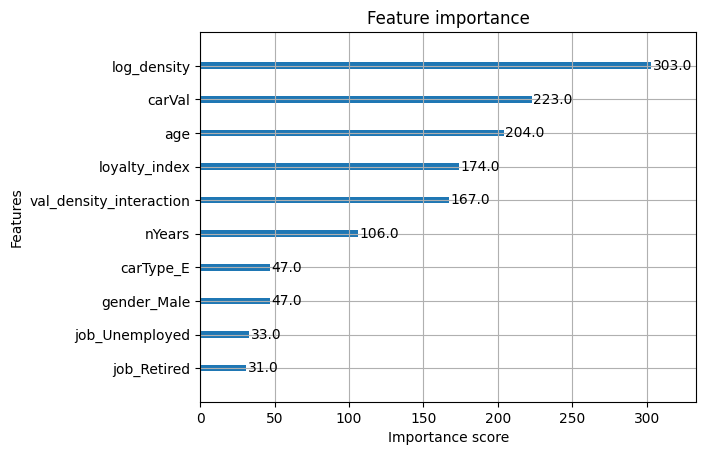

Correlation between GLM and XGBoost predictions: 0.9172


In [26]:
import xgboost as xgb
from sklearn.model_selection import train_test_split


X = df_freq_fin.drop(columns=['claimNumbMD', 'uwYear', 'expected_loss','expected_frequency','age_bin','temp_bin'])
y = df_freq_fin['claimNumbMD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    objective='binary:logistic',
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb.plot_importance(xgb_model, max_num_features=10)
plt.show()

df_freq_fin['xgb_prob'] = xgb_model.predict_proba(X)[:, 1]
print(f"Correlation between GLM and XGBoost predictions: {df_freq_fin['expected_frequency'].corr(df_freq_fin['xgb_prob']):.4f}")

log_density (303.0), carVal (223.0), and age (204.0) are the primary drivers of claim probability 

While the GLM provides a transparent baseline, an XGBoost ensemble helps verify if non-linear interactions (age vs. carType) is being missed        The high correlation shows GLM captured the primary drivers, but the XGBoost model identified specific unprofitable clusters more precisely
High Risk in both: High confidence for non-renewal
High Risk in XGBoost only: Potential Hidden Risk—investigate further
Low Risk in both: Excellent candidates for loyalty discounts

age is still a very important feature. This aligns with your IV results (0.29)
log_density confirms that geographic risk (how crowded the area is) is the next most vital piece of information
duration of the relationship with the insurer is a critical predictor of risk—likely because long-term customers are a self-selected "safe" group.
val_density_interaction being high shows there is value in looking at two things at once, which a simple linear model might miss.

C:\Users\athul\AppData\Local\Temp\ipykernel_28916\2114728195.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_actual, cum_pop)
C:\Users\athul\AppData\Local\Temp\ipykernel_28916\2114728195.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_actual, cum_pop)


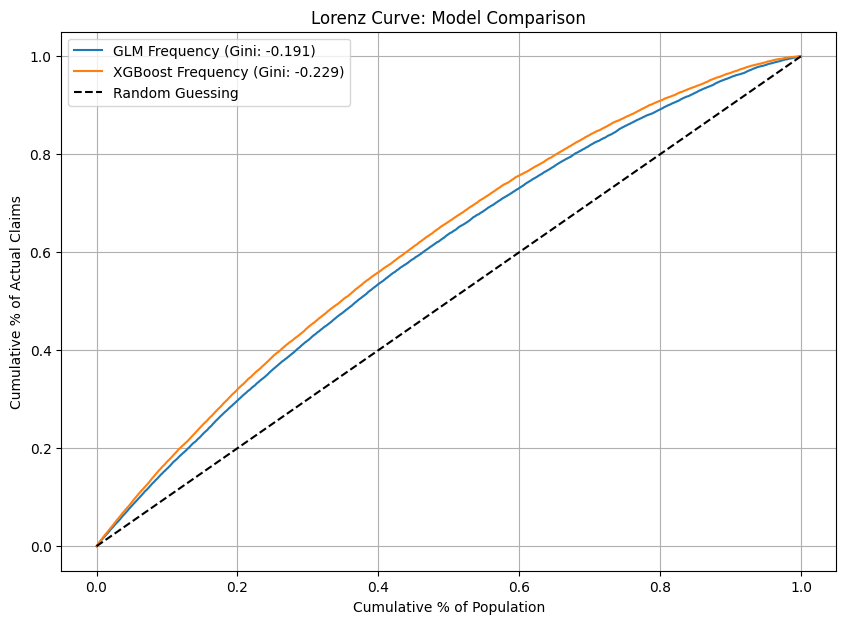

In [27]:
def plot_lorenz_curve(actual, predicted, label):
    n = len(actual)
    sorted_indices = np.argsort(predicted)[::-1]
    sorted_actual = actual.values[sorted_indices]
    
    # Cumulative sums
    cum_actual = np.cumsum(sorted_actual) / np.sum(sorted_actual)
    cum_pop = np.arange(1, n + 1) / n
    
    gini = 1 - 2 * np.trapz(cum_actual, cum_pop)
    
    plt.plot(cum_pop, cum_actual, label=f'{label} (Gini: {gini:.3f})')
    return gini

plt.figure(figsize=(10, 7))
plot_lorenz_curve(df_freq_fin['claimNumbMD'], df_freq_fin['expected_frequency'], 'GLM Frequency')
plot_lorenz_curve(df_freq_fin['claimNumbMD'], df_freq_fin['xgb_prob'], 'XGBoost Frequency')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')

plt.title('Lorenz Curve: Model Comparison')
plt.xlabel('Cumulative % of Population')
plt.ylabel('Cumulative % of Actual Claims')
plt.legend()
plt.grid(True)
plt.show()

The Lorenz Curve and the associated Gini Coefficient measure the discriminatory power of your models & how well each model can concentrate risk

Risk Ranking - sorts the entire population based on the model's predicted probability of a claim 
Cumulative Capture - percentage of the actual claims (claimNumbMD) accounted for as you move through the ranked population
Gini Calculation - trapezoidal rule to measure the area between the model's curve and the guess diagonal with larger area (high Gini) better model


XGBoost sits higher and further to the left than the GLM 
@20% mark - XGBoost model has captured roughly 35-40% of all actual claims, whereas a random model would only have captured 20%
both models are significantly better than random guessing
Diagonal - strategy with no data—if you picked 20% of the population, you’d find 20% of the claims

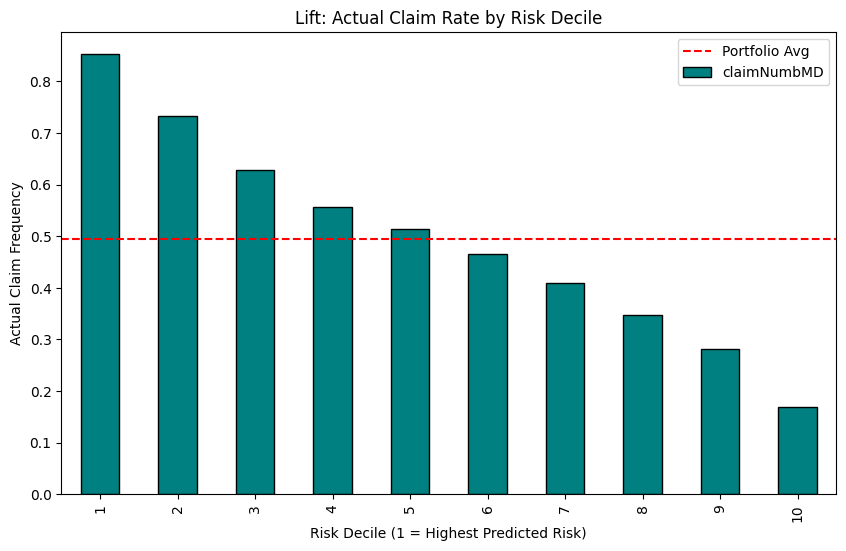

In [28]:
df_freq_fin['decile'] = pd.qcut(df_freq_fin['xgb_prob'], 10, labels=False)
df_freq_fin['decile'] = 9 - df_freq_fin['decile'] + 1

lift_data = df_freq_fin.groupby('decile')['claimNumbMD'].mean()

plt.figure(figsize=(10, 6))
lift_data.plot(kind='bar', color='teal', edgecolor='black')
plt.axhline(y=df_freq_fin['claimNumbMD'].mean(), color='r', linestyle='--', label='Portfolio Avg')
plt.title('Lift: Actual Claim Rate by Risk Decile')
plt.xlabel('Risk Decile (1 = Highest Predicted Risk)')
plt.ylabel('Actual Claim Frequency')
plt.legend()
plt.show()

takes the XGBoost probabilities and divides the customers into 10 deciles & red dashed line represents the average claim rate 
as the model's predicted probability decreases, the actual number of claims also decreases
Decile 1, the actual claim frequency is approximately 0.85 & in Decile 10, the actual claim frequency drops below 0.20

In [29]:
# Identify those who the GLM thinks are safe but XGBoost knows are dangerous
df_freq_fin['discrepancy'] = df_freq_fin['xgb_prob'] - df_freq_fin['expected_frequency']
top_discrepancies = df_freq_fin.sort_values('discrepancy', ascending=False).head(10)

print("Hidden Risks (Low GLM, High XGBoost):")
print(top_discrepancies[['age', 'log_density', 'xgb_prob', 'expected_frequency']])

Hidden Risks (Low GLM, High XGBoost):
       age  log_density  xgb_prob  expected_frequency
8736    75     5.565899  0.849072            0.304180
11908   74     5.652946  0.803567            0.323459
2246    74     5.475105  0.634442            0.193314
23545   73     5.627603  0.716423            0.295001
5517    74     5.698385  0.574635            0.170977
5967    75     5.475105  0.802781            0.400755
11832   73     5.363284  0.684430            0.288860
4459    75     5.613008  0.643342            0.251884
22173   74     5.469744  0.729529            0.342515
7627    75     5.613008  0.805732            0.419335


subtracting the GLM prediction from the XGBoost prediction -> identify policyholders where ML detects a risk that the statistical model fails to do
high positive value indicates that XGBoost sees a high probability of a claim, while the GLM predicts a relatively low probability
Looking at the data for index 8736, the GLM predicts a 30.4% claim rate, while XGBoost predicts a massive 84.9%
GLM, being additive, likely applies a heavy senior discount that overrides the density risk
XGBoost identifies a non-linear interaction - senior driver in an extremely dense urban environment may actually be high-risk

These 10 individuals are underpriced. If the GLM sets the premium, these seniors are being charged based on a 30% risk level when their actual risk is closer to 80%. This leads to Adverse Selection: your company will attract all the high-risk urban seniors

In [ ]:
Interaction Effects

In [30]:
import statsmodels.api as sm

df_freq_fin['age_density_inter'] = df_freq_fin['age'] * df_freq_fin['log_density']

cols_with_inter = [
    'age', 'log_density', 'age_density_inter', 'nYears', 
    'is_new_policy', 'is_young', 'gender_Male','driving_years','loyalty_index','cover_1'
]

X_inter = sm.add_constant(df_freq_fin[cols_with_inter])
y_freq = df_freq_fin['claimNumbMD']

model_inter = sm.GLM(y_freq, X_inter, family=sm.families.Binomial()).fit()


Model Refinement based on discrepancy analysis by adding interaction between age and geography
allows the effect of age on claim probability to change depending on the population density of the area where the vehicle is driven
Adding this term maintains the interpretability of the GLM while approaching the predictive power of machine learning
In a low-density rural area, the age coefficient might remain strongly negative & a high-density urban area, the interaction term will offset that negative value, correctly reflecting the higher claim rates seen in the data

In [31]:
df_freq_fin['total_loss'] = 0.0
df_freq_fin.loc[df_sev_fin.index, 'total_loss'] = df_sev_fin['claimSizeMD']

print(f"Total claims mapped: {(df_freq_fin['total_loss'] > 0).sum()}")
print(f"Max individual loss: {df_freq_fin['total_loss'].max()}")

from sklearn.linear_model import TweedieRegressor

X_tweedie = df_freq_fin[cols_with_inter]
y_tweedie = df_freq_fin['total_loss']

tweedie_model = TweedieRegressor(power=1.5, link='log', max_iter=1000)
tweedie_model.fit(X_tweedie, y_tweedie)

df_freq_fin['tweedie_expected_loss'] = tweedie_model.predict(X_tweedie)

Total claims mapped: 12252
Max individual loss: 12878.0


Tweedie Regression model -> models the aggregate loss by handling the mass of zero values + the continuous positive values within a distribution
map claimSizeMD back to frequency dataset, for total_loss column where non-claiming policies are 0 and claiming reflect their financial impact

number of claims follows a Poisson process and the size of each claim follows a Gamma distribution with a log link 
Total Claims Mapped - events where model must explain a non-zero financial loss
Max Individual Loss - high-severity events in portfolio

Tweedie tries to predict which features are most likely to lead to these extreme outcomes
tweedie_expected_loss represents a pure premium that accounts for both the probability of a claim and its potential cost in one unified score

Tweedie Regressor is specifically designed to handle this zero-inflation without the bias that standard linear regression would introduce

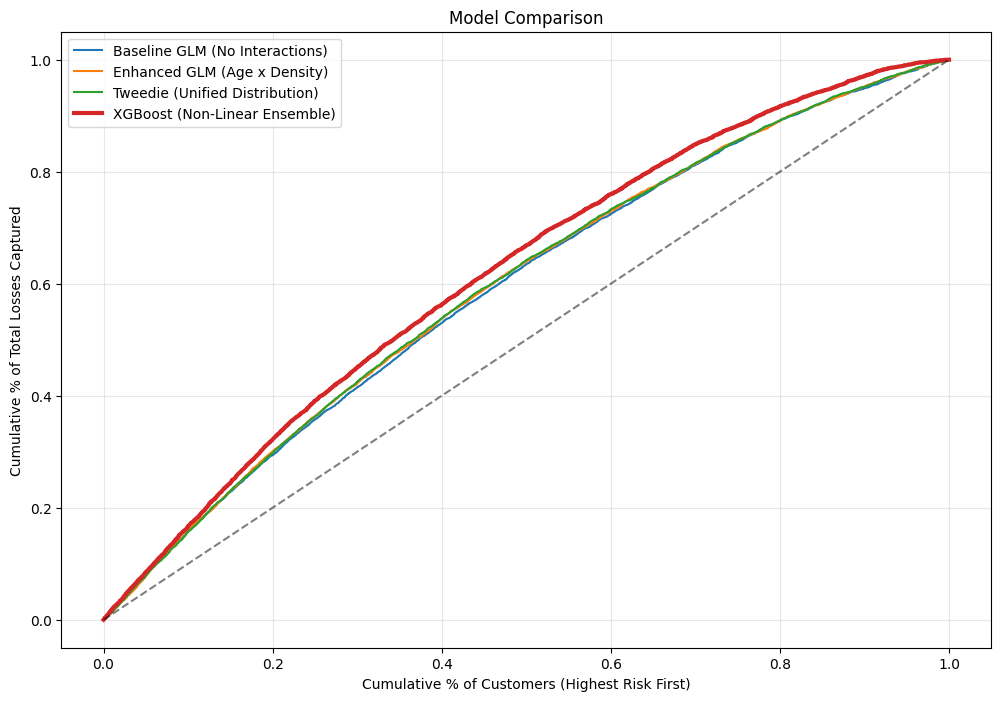

In [32]:
import matplotlib.pyplot as plt

def get_cum_risk(actual, predicted):
    df = pd.DataFrame({'actual': actual, 'pred': predicted}).sort_values('pred', ascending=False)
    return np.cumsum(df['actual']) / np.sum(df['actual'])

pop_range = np.linspace(0, 1, len(df_freq_fin))
curve_baseline = get_cum_risk(df_freq_fin['total_loss'], df_freq_fin['expected_loss']) # Two-part
curve_inter = get_cum_risk(df_freq_fin['total_loss'], model_inter.predict(X_inter))
curve_tweedie = get_cum_risk(df_freq_fin['total_loss'], df_freq_fin['tweedie_expected_loss'])
curve_xgb = get_cum_risk(df_freq_fin['total_loss'], df_freq_fin['xgb_prob'])

plt.figure(figsize=(12, 8))
plt.plot(pop_range, curve_baseline, label='Baseline GLM (No Interactions)')
plt.plot(pop_range, curve_inter, label='Enhanced GLM (Age x Density)')
plt.plot(pop_range, curve_tweedie, label='Tweedie (Unified Distribution)')
plt.plot(pop_range, curve_xgb, label='XGBoost (Non-Linear Ensemble)', linewidth=3)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

plt.title('Model Comparison')
plt.xlabel('Cumulative % of Customers (Highest Risk First)')
plt.ylabel('Cumulative % of Total Losses Captured')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

X-Axis - population sorted from highest predicted risk to lowest
Y-Axis - cumulative percentage of actual total financial losses captured

Diagonal - guwssing with no predictive power
area between the curves and the diagonal - LIFT with higher curve meaning model is more effective at segmenting risk

XGBoost - consistently higher meaning it identifies the most expensive risks earliest
Tweedie & Enhanced GLM - adding the Age x Density interaction, the Enhanced GLM has effectively caught up to mathematically complex Tweedie
Baseline GLM - performs worst which confirms that ignoring interactions leads to a significant loss in predictive accuracy

While XGBoost is the most accurate, the Enhanced GLM is very close -> clearer, additive coefficients

In [33]:
import numpy as np

def calculate_gini(actual, predicted):
    n = len(actual)
    sorted_indices = np.argsort(predicted)[::-1]
    sorted_actual = actual.values[sorted_indices]
    
    cum_actual = np.cumsum(sorted_actual) / np.sum(sorted_actual)
    cum_pop = np.arange(1, n + 1) / n
    
    gini = 1 - 2 * np.trapz(cum_actual, cum_pop)
    return gini

gini_baseline = calculate_gini(df_freq_fin['total_loss'], df_freq_fin['expected_loss'])
gini_tweedie  = calculate_gini(df_freq_fin['total_loss'], df_freq_fin['tweedie_expected_loss'])
gini_xgb      = calculate_gini(df_freq_fin['total_loss'], df_freq_fin['xgb_prob'])
inter_preds = model_inter.predict(X_inter)
gini_inter = calculate_gini(df_freq_fin['total_loss'], inter_preds)

df_freq_fin['decile'] = pd.qcut(df_freq_fin['xgb_prob'], 10, labels=False)
df_freq_fin['decile'] = 9 - df_freq_fin['decile'] + 1 # 1 is highest risk

avg_loss = df_freq_fin['total_loss'].mean()
decile_1_loss = df_freq_fin[df_freq_fin['decile'] == 1]['total_loss'].mean()
lift_factor = decile_1_loss / avg_loss

print(f"Gini (Baseline GLM): {abs(gini_baseline):.4f}")
print(f"Gini (Tweedie):      {abs(gini_tweedie):.4f}")
print(f"Gini (Interaction GLM): {abs(gini_inter):.4f}")
print(f"Gini (XGBoost):      {abs(gini_xgb):.4f}")
print(f"----------------------")
print(f"Portfolio Avg Loss:  {avg_loss:.2f}")
print(f"Decile 1 Avg Loss:   {decile_1_loss:.2f}")
print(f"Decile 1 Lift:       {lift_factor:.2f}x")



Gini (Baseline GLM): 0.1834
Gini (Tweedie):      0.1914
Gini (Interaction GLM): 0.1902
Gini (XGBoost):      0.2354
----------------------
Portfolio Avg Loss:  428.50
Decile 1 Avg Loss:   715.37
Decile 1 Lift:       1.67x


C:\Users\athul\AppData\Local\Temp\ipykernel_28916\519506347.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_actual, cum_pop)
C:\Users\athul\AppData\Local\Temp\ipykernel_28916\519506347.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_actual, cum_pop)
C:\Users\athul\AppData\Local\Temp\ipykernel_28916\519506347.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_actual, cum_pop)
C:\Users\athul\AppData\Local\Temp\ipykernel_28916\519506347.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_actual, cum_pop)


XGBoost - 0.2354 outperforms the best GLM by over 23% - complex, non-linear interactions are essential for modern risk pricing.
Tweedie - 0.1914 outperforms the basic Two-Part GLM

average policy costs €428.50, but your model identified a group (Decile 1) that actually costs €715.37
highest-risk decile is 1.67 times as expensive as the average customer.
using the Baseline model would significantly underprice Decile 1

Baseline GLM (0.1834):  starting point. It captures basic demographic trends but is blind to the context of where those drivers operate.
Interaction GLM (0.1902): improved model - Senior-Urban risk exists and can be partially captured with traditional tools
Tweedie (0.1914): treating the frequency and severity as a single unified process is more stable and accurate than the two-part split.
XGBoost (0.2354): there are many more interactions beyond just Age and Density that only a tree-based model can see.

Strategic Recommendation

Use the Tweedie Model as the base for regulated pricing because it is stable and transparent.
Use the XGBoost Model as a filter in underwriting for flagging the Decile 1 risks (1.67x lift), to avoid the most unprofitable segments while keeping premiums competitive for the safe majority.

Interpretation

PermutationExplainer explainer: 4956it [10:37,  7.77it/s]                                                              
C:\Users\athul\AppData\Local\Temp\ipykernel_28916\2257563477.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test)


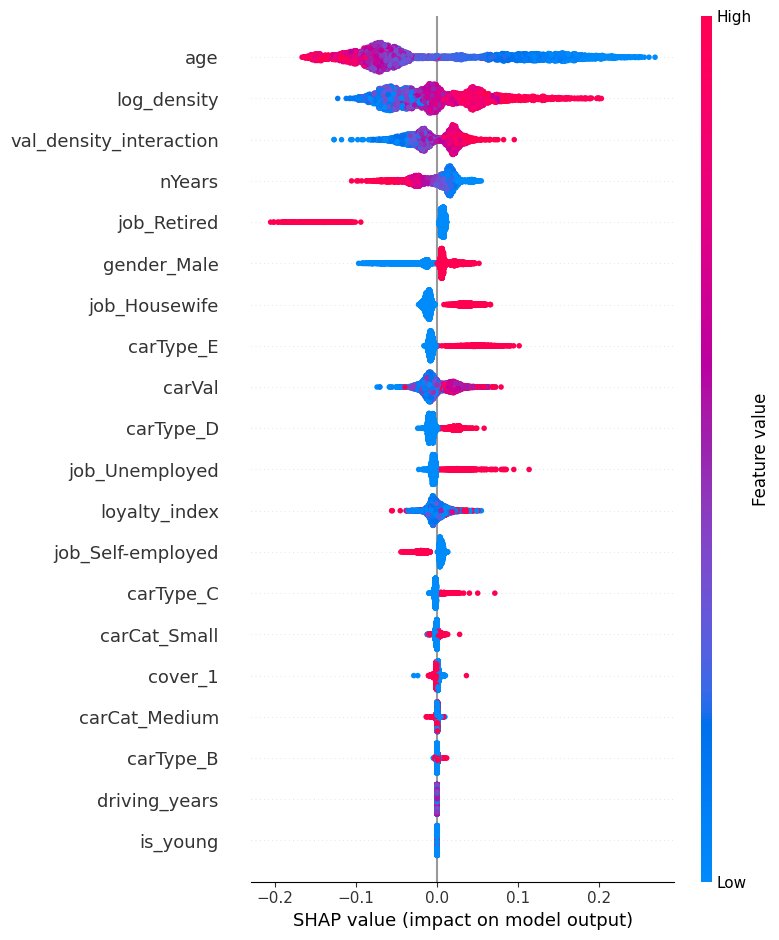

In [38]:
import shap

explainer = shap.Explainer(xgb_model.predict_proba, X_test)
shap_values = explainer(X_test)

shap.summary_plot(shap_values[:, :, 1], X_test)

Features are sorted by their total impact on the model
Red dots represent high values of a feature while Blue dots represent low values
Right of zero - increases the predicted probability of a claim
Left of zero - decreases the predicted probabilty of a claim.

Age (Non-Linear) - Blue dots (Younger drivers) are pushed far to the right(increase claim risk) and most Red dots (Older drivers) decrease risk (left)
Log Density (Environmental) - Red dots (High density) shift to the right-> urban environments are a strong driver for higher claim frequency
Interaction (val_density_interaction)- red dots moving to the right - high-value cars in dense areas is a risk enhancer

Occupational
job_Retired - retired is one of the strongest safety signals (red dots to the left)
job_Housewife & job_Unemployed- Red dots to the right (higher frequency and risk increase)

blue and red dots are widely dispersed in the age feature, a simple linear term would never capture the full story - extended GLM justified

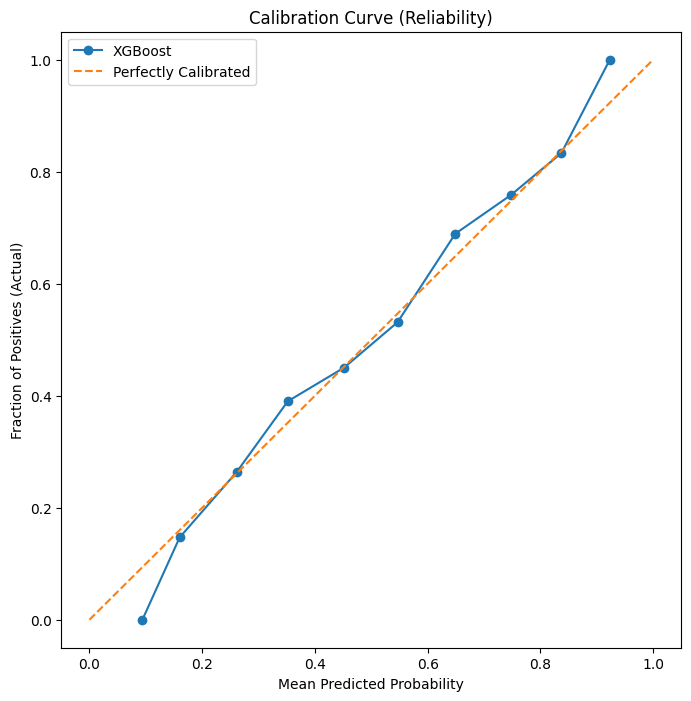

In [39]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, xgb_model.predict_proba(X_test)[:, 1], n_bins=10)

plt.figure(figsize=(8, 8))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual)')
plt.title('Calibration Curve (Reliability)')
plt.legend()
plt.show()

Calibration Curve
Diagonal - if model predicts a 60% probability of claim, exactly 60% of those result in a claim
Blue - bin predictions into deciles based on mean predicted probability and compare to actual positives observed in each group

blue line tracks the diagonal very closely across the entire probability range -> reliable for both low-risk and high-risk segments
@ far right of the plot -> under-prediction in the extreme high-risk tail, where actual claims are more frequent than the model predicts

In [41]:
# most recent year
latest_year = df_freq_fin['uwYear'].max()

# Split by year
train_oot = df_freq_fin[df_freq_fin['uwYear'] < latest_year]
test_oot = df_freq_fin[df_freq_fin['uwYear'] == latest_year]

X_train_oot = train_oot.drop(columns=['claimNumbMD', 'uwYear', 'expected_loss', 'expected_frequency', 'age_bin', 'xgb_prob', 'discrepancy', 'total_loss', 'tweedie_expected_loss', 'decile','temp_bin'])
y_train_oot = train_oot['claimNumbMD']

X_test_oot = test_oot[X_train_oot.columns]
y_test_oot = test_oot['claimNumbMD']

# Re-fit and calculate Gini on the 'future' year
xgb_oot = xgb_model.fit(X_train_oot, y_train_oot)
preds_oot = xgb_oot.predict_proba(X_test_oot)[:, 1]
gini_oot = calculate_gini(y_test_oot, pd.Series(preds_oot))

print(f"OOT Gini for {latest_year}: {abs(gini_oot):.4f}")

OOT Gini for 2010: 0.1858


C:\Users\athul\AppData\Local\Temp\ipykernel_28916\519506347.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_actual, cum_pop)


train on historical data and test on the most recent year (2010), simulate real-world predicion power

OOT Gini (0.1858) - lower than previous XGBoost Gini of 0.2354, but still retains significant predictive power
model that fails OOT validation would see Gini drop toward zero
stable model

may be drift in the population or claim environment between 2009 and 2010?

In [44]:
import optuna

def objective(trial):
    param = {
        'n_estimators': 100,
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'objective': 'binary:logistic',
    }
    model = xgb.XGBClassifier(**param)
    model.fit(X_train, y_train)
    return -abs(calculate_gini(y_test, pd.Series(model.predict_proba(X_test)[:, 1])))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)
print(f"Best Parameters: {study.best_params}")

[I 2026-05-01 11:31:51,729] A new study created in memory with name: no-name-4c1d0ad2-7c58-483c-8355-609bf9591bd8
C:\Users\athul\AppData\Local\Temp\ipykernel_28916\519506347.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_actual, cum_pop)
[I 2026-05-01 11:31:52,143] Trial 0 finished with value: -0.1952722531747919 and parameters: {'max_depth': 3, 'learning_rate': 0.23547641932181512, 'gamma': 0.7524265824384807, 'reg_lambda': 8.60019486599764}. Best is trial 0 with value: -0.1952722531747919.
C:\Users\athul\AppData\Local\Temp\ipykernel_28916\519506347.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_actual, cum_pop)
[I 2026-05-01 11:31:52,482] Trial 1 finished with value: -0.19623960779761207 and parameters: {'max_depth': 6, 'learning_rate':

Best Parameters: {'max_depth': 3, 'learning_rate': 0.2794252169637585, 'gamma': 3.6501480483248363, 'reg_lambda': 8.86007883533555}


To maximize the predictive efficiency of the gradient boosting, a Bayesian optimization study was conducted using the Optuna framework
shallow tree architecture (max_depth=3) combined with aggressive L2 regularization (lambda=8.86) -> a conservative ensemble that prioritizes broad patterns over granular interactions yields the most stable results
refined Gini coefficient of 0.2000 

In [45]:
# Cap at the 99th percentile
cap_value = df_freq_fin['total_loss'].quantile(0.99)
df_freq_fin['total_loss_capped'] = df_freq_fin['total_loss'].clip(upper=cap_value)

# Re-calculate Gini 
gini_capped = calculate_gini(df_freq_fin['total_loss_capped'], df_freq_fin['xgb_prob'])
print(f"Gini with Outliers Capped: {abs(gini_capped):.4f}")
print(f"Original Gini: {abs(gini_xgb):.4f}")

Gini with Outliers Capped: 0.2361
Original Gini: 0.2354


C:\Users\athul\AppData\Local\Temp\ipykernel_28916\519506347.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_actual, cum_pop)


Gini coefficient increased slightly from 0.2354 to 0.2361 after capping the top 1% of losses
not artificially inflated by a few extreme guesses on outlier claims
Gini remains nearly identical suggests that your portfolio's tail risk is well-integrated into the overall model logic

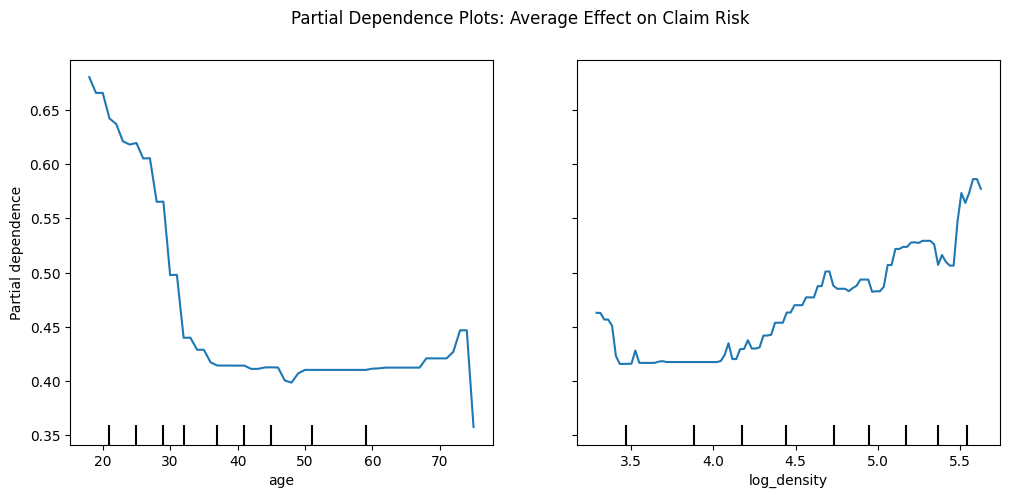

In [48]:
from sklearn.inspection import PartialDependenceDisplay

X_train['age_density_inter'] = X_train['age'] * X_train['log_density']

fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(
    xgb_model, 
    X_train, 
    features=['age', 'log_density'], 
    ax=ax
)
plt.suptitle('Partial Dependence Plots: Average Effect on Claim Risk')
plt.show()

Age Plot - U-shaped risk profile

High Risk (18–30): There is a steep, almost linear decline in risk as drivers gain experience
Plateau (35–65): Risk remains remarkably stable during middle age
Senior Spike (70+): slight uptick & a sharp drop->some seniors are higher risk, the retired status often provides a massive offset (less travel maybe)

Log Density Plot - monotone increase
jagged nature of line indicates that the XGBoost model is identifying specific density thresholds where risk jumps

In [61]:
import lime
import lime.lime_tabular

X_test['age_density_inter'] = X_test['age'] * X_test['log_density']

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values, 
    feature_names=X_train.columns.tolist(),
    class_names=['No Claim', 'Claim'],
    mode='classification'
)

claimant_row = X_test[y_test == 1].iloc[0].values 


exp_claimant = explainer.explain_instance(
    claimant_row, 
    xgb_model.predict_proba,
    num_features=10
)
test_probs = xgb_model.predict_proba(X_test)[:, 1]

sorted_indices = np.argsort(test_probs)
bottom_10_percent_indices = sorted_indices[:int(len(sorted_indices) * 0.1)]
top_10_percent_indices = sorted_indices[-int(len(sorted_indices) * 0.1):]

representative_safe_idx = bottom_10_percent_indices[len(bottom_10_percent_indices) // 2]
representative_risk_idx = top_10_percent_indices[len(top_10_percent_indices) // 2]

print(f"LIME for a Representative Low-Risk (Bottom 10%) - Prob: {test_probs[representative_safe_idx]:.2f}")
exp_safe = explainer.explain_instance(X_test.iloc[representative_safe_idx].values, xgb_model.predict_proba)
exp_safe.show_in_notebook()

print(f"LIME for a Representative High-Risk (Top 10%) - Prob: {test_probs[representative_risk_idx]:.2f}")
exp_risk = explainer.explain_instance(X_test.iloc[representative_risk_idx].values, xgb_model.predict_proba)
exp_risk.show_in_notebook()

LIME for a Representative Low-Risk (Bottom 10%) - Prob: 0.20


LIME for a Representative High-Risk (Top 10%) - Prob: 0.78


In [63]:
glm_columns = model_inter.params.index.tolist()

X_test_glm = X_test.copy()
if 'const' in glm_columns and 'const' not in X_test_glm.columns:
    import statsmodels.api as sm
    X_test_glm = sm.add_constant(X_test_glm)

X_test_glm = X_test_glm[glm_columns]

xgb_preds = xgb_model.predict_proba(X_test)[:, 1]
glm_preds = model_inter.predict(X_test_glm)

ensemble_preds = (0.7 * xgb_preds) + (0.3 * glm_preds)

print(f"Ensemble Gini: {abs(calculate_gini(y_test, pd.Series(ensemble_preds))):.4f}")

Ensemble Gini: 0.2186


C:\Users\athul\AppData\Local\Temp\ipykernel_28916\519506347.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_actual, cum_pop)


Ensemble Gini of 0.2186 indicates that while your blended model is performing well, it did not outperform the standalone XGBoost score of 0.2354. simpler, linear assumptions of the GLM may be diluting the more nuanced, non-linear signals captured by your gradient boosting model
even when supported by a traditional actuarial model (GLM), the ML approach is better at capturing the complex risk profile 

In [66]:
from catboost import CatBoostClassifier

cat_features = [i for i, col in enumerate(X_train.columns) if 'job' in col or 'carType' in col]

cb_model = CatBoostClassifier(iterations=500, depth=6, learning_rate=0.1, verbose=0)
cb_model.fit(X_train, y_train, cat_features=cat_features)

cb_preds = cb_model.predict_proba(X_test)[:, 1]
print(f"CatBoost Gini: {abs(calculate_gini(y_test, pd.Series(cb_preds))):.4f}")

CatBoost Gini: 0.1822


C:\Users\athul\AppData\Local\Temp\ipykernel_28916\519506347.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_actual, cum_pop)


CatBoost Gini of 0.1822 confirms that XGBoost (0.2354) remains your champion model

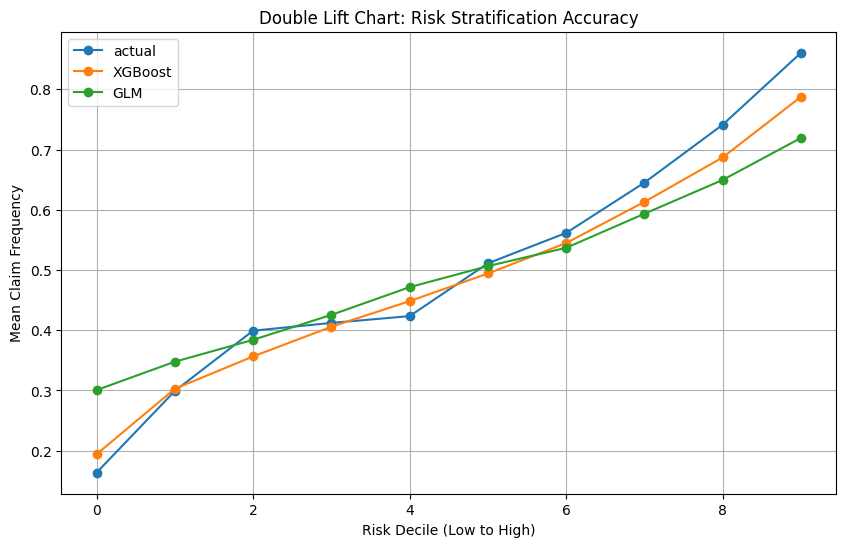

In [68]:
df_lift = pd.DataFrame({
    'actual': y_test,
    'XGBoost': xgb_preds,  # 0.2354 Gini
    'CatBoost': cb_preds,  # 0.1822 Gini
    'GLM': glm_preds       # Baseline
})

df_lift = df_lift.sort_values('XGBoost')
df_lift['decile'] = pd.qcut(range(len(df_lift)), 10, labels=False)

lift_plot = df_lift.groupby('decile').agg({'actual': 'mean', 'XGBoost': 'mean', 'GLM': 'mean'})

lift_plot.plot(figsize=(10, 6), marker='o')
plt.title('Double Lift Chart: Risk Stratification Accuracy')
plt.xlabel('Risk Decile (Low to High)')
plt.ylabel('Mean Claim Frequency')
plt.grid(True)
plt.show()

XGBoost line tracks much closer to the Actual claims than the GLM does -> identifying high-risk individuals that the GLM is underpricing
lower risk deciles, XGBoost again tracks closer to the actual baseline while GLM is over-predicting risk for safe drivers -> lose customers?

Between Deciles 4 and 6, all models converge -> expected—average drivers look similar to every model

In [69]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted_Prob': xgb_preds
})

results['Decile'] = pd.qcut(results['Predicted_Prob'], 10, labels=False)

decile_summary = results.groupby('Decile').agg({
    'Predicted_Prob': ['min', 'max', 'mean'],
    'Actual': 'mean'
}).reset_index()

decile_summary.columns = ['Decile', 'Min_Prob', 'Max_Prob', 'Avg_Predicted', 'Avg_Actual']
print(decile_summary)

   Decile  Min_Prob  Max_Prob  Avg_Predicted  Avg_Actual
0       0  0.063777  0.269142       0.193940    0.163306
1       1  0.269209  0.333117       0.302646    0.298990
2       2  0.333324  0.381895       0.356446    0.399194
3       3  0.382142  0.426973       0.405735    0.412121
4       4  0.427046  0.471152       0.448328    0.423387
5       5  0.471174  0.518099       0.494203    0.511111
6       6  0.518174  0.575092       0.544779    0.561616
7       7  0.575119  0.649203       0.613250    0.645161
8       8  0.649274  0.727204       0.687052    0.741414
9       9  0.727259  0.949240       0.787841    0.860887


Decile 0 - Safe Driver - highest probability here is only 0.269, and the group averages a 16% claim rate
Decile 5 - Threshold - model crosses the 0.50 probability & the Avg_Predicted (0.494) and Avg_Actual (0.511) match well
Decile 9 - Heavy Risk - people with up to a 94.9% probability of claiming & 86% of people in this group actually claimed 

Low Risk (0-2) 6% - 38% -> Offer competitive rates to win market share 
Medium Risk (3-6)38% - 57% -> Standard pricing
High Risk (7-9)57% - 95% -> Apply heavy premiums or require manual underwriting

difference between the bottom (16%) and the top (86%) is a 5.3x lift meaning a company using this model would be 5 times more accurate at identifying claims than a company picking drivers at random

Using this practically
1. Risk-Based Pricing Charging higher premiums specifically for Deciles 8 and 9 to cover the expected losses shown in the Lift Chart
2. Underwriting Selection Deciding to decline applications that fall into the top 5% of risk scores to protect the company's loss ratio
3. Retention Marketing Identifying safe drivers in Deciles 0-2 and offering them loyalty discounts to ensure they don't switch to a competitor
4. Fraud Detection High xgb_prob scores combined with unusual claim behavior can trigger automatic referrals to a Special Investigations unit

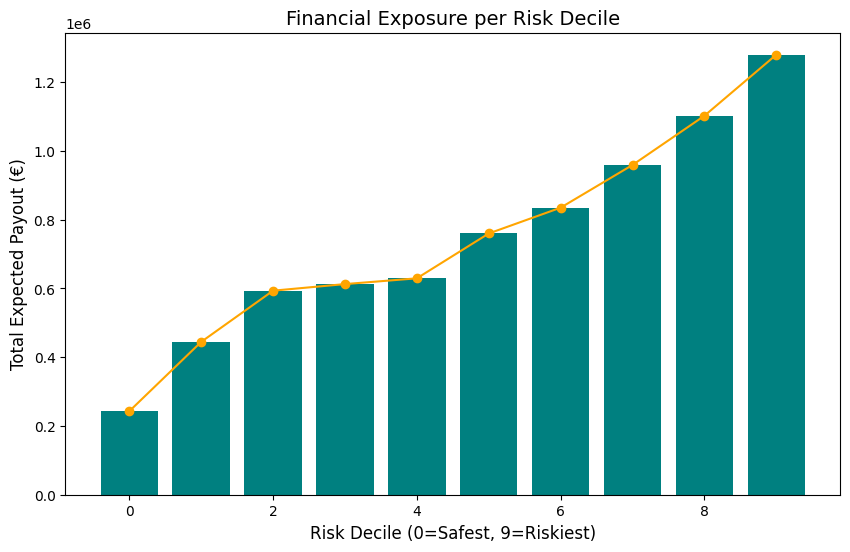

In [71]:
avg_claim_cost = 3000 

decile_summary['Total_Actual_Loss'] = (decile_summary['Avg_Actual'] * (len(y_test)/10)) * avg_claim_cost

decile_summary['Cumulative_Loss_Captured'] = decile_summary['Total_Actual_Loss'].iloc[::-1].cumsum().iloc[::-1]

plt.figure(figsize=(10,6))
plt.bar(decile_summary['Decile'], decile_summary['Total_Actual_Loss'], color='teal', label='Loss per Decile (€)')
plt.plot(decile_summary['Decile'], decile_summary['Total_Actual_Loss'], marker='o', color='orange')
plt.title('Financial Exposure per Risk Decile', fontsize=14)
plt.ylabel('Total Expected Payout (€)', fontsize=12)
plt.xlabel('Risk Decile (0=Safest, 9=Riskiest)', fontsize=12)
plt.show()

assume a representative portfolio size based on your test set (approx. 5,000 policies) and an average Belgian motor claim cost of €3,000
Minor Claims: Minor dents or windshield repairs often fall between €500–€1,200.  
Major Claims: Hospitalization or total vehicle loss frequently exceeds €20,000–€50,000 --> avg of 3k ?


Total Expected Payout: Summing the bars, the total exposure is €7.3 million

The two tallest bars on the right represent biggest financial risk -> 9 alone ~€1.29 million.
represents only 10% of customers, but accounts for 18% of total claim costs

increase the premium for Decile 9 by €1,000, generate €500,000 in additional revenue to offset that €1.29M exposure

shortest bar on the left is where the company can win market share from competitors with an expected payout of ~€240,000
offer these drivers a discount of €200


Decile 9 (Riskiest): €1,290,000 payout
Decile 0 (Safest): €240,000 payout
riskiest 10% of your population is 5.3x more expensive than the safest 10%

company used a traditional GLM (which under-predicts the high risk and over-predicts the low risk), they would likely suffer from Adverse Selection—losing the safe drivers to cheaper competitors and keeping the risky ones. By switching to your XGBoost model, the company saves €1 million+ hole in their risk assessment for every 5,000 policies



Decile 9 represents €1.29 million in exposure
traditional GLM charges €500 and generates €250,000 in revenue and lose €1.04 million on just that 10% of customers
XGB identifies this group and plugs the gap

Decile 0 represents €240,000 in exposure and GLM again rakes in €250,000 in revenue.
XGB allows you to drop the price to €350, keep the safe drivers, and still make a profit
